In [2]:
import os
os.listdir()

['.config', 'Network_anomaly_data.csv', 'sample_data']

In [3]:
import pandas as pd

df = pd.read_csv("Network_anomaly_data.csv")

df.head()

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
print(df.shape)
print(df.info())

(125973, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                125973 non-null  int64  
 1   protocoltype            125973 non-null  object 
 2   service                 125973 non-null  object 
 3   flag                    125973 non-null  object 
 4   srcbytes                125973 non-null  int64  
 5   dstbytes                125973 non-null  int64  
 6   land                    125973 non-null  int64  
 7   wrongfragment           125973 non-null  int64  
 8   urgent                  125973 non-null  int64  
 9   hot                     125973 non-null  int64  
 10  numfailedlogins         125973 non-null  int64  
 11  loggedin                125973 non-null  int64  
 12  numcompromised          125973 non-null  int64  
 13  rootshell               125973 non-null  int64  
 14  suattem

Basic Data Cleaning

In [5]:
df = df.drop_duplicates()
print(df.shape)

(125973, 43)


In [6]:
df.columns = [col.lower() for col in df.columns]
print(df.columns)

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag'],
      dtype='object')


In [7]:
print(df['attack'].value_counts())

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


Create Target Variable

In [8]:
df['label'] = df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

print(df['label'].value_counts())

label
0    67343
1    58630
Name: count, dtype: int64


In [9]:
df = df.drop('attack', axis=1)

In [10]:
categorical_cols = ['protocoltype', 'service', 'flag']
print(categorical_cols)

['protocoltype', 'service', 'flag']


In [11]:
df = pd.get_dummies(df, columns=categorical_cols)
print(df.shape)

(125973, 124)


EDA (Exploratory Data Analysis)

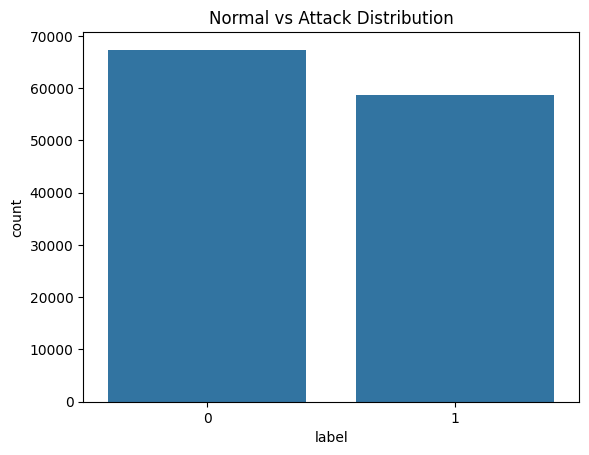

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Normal vs Attack Distribution")
plt.show()
#Distribution of Target

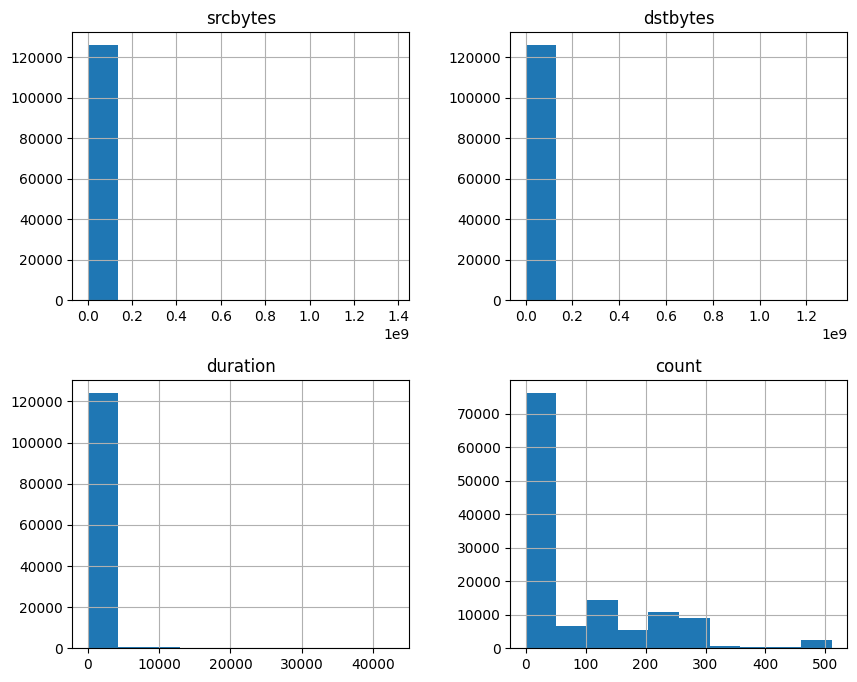

In [14]:
cols = ['srcbytes', 'dstbytes', 'duration', 'count']

df[cols].hist(figsize=(10,8))
plt.show()
#Check Numerical Distribution

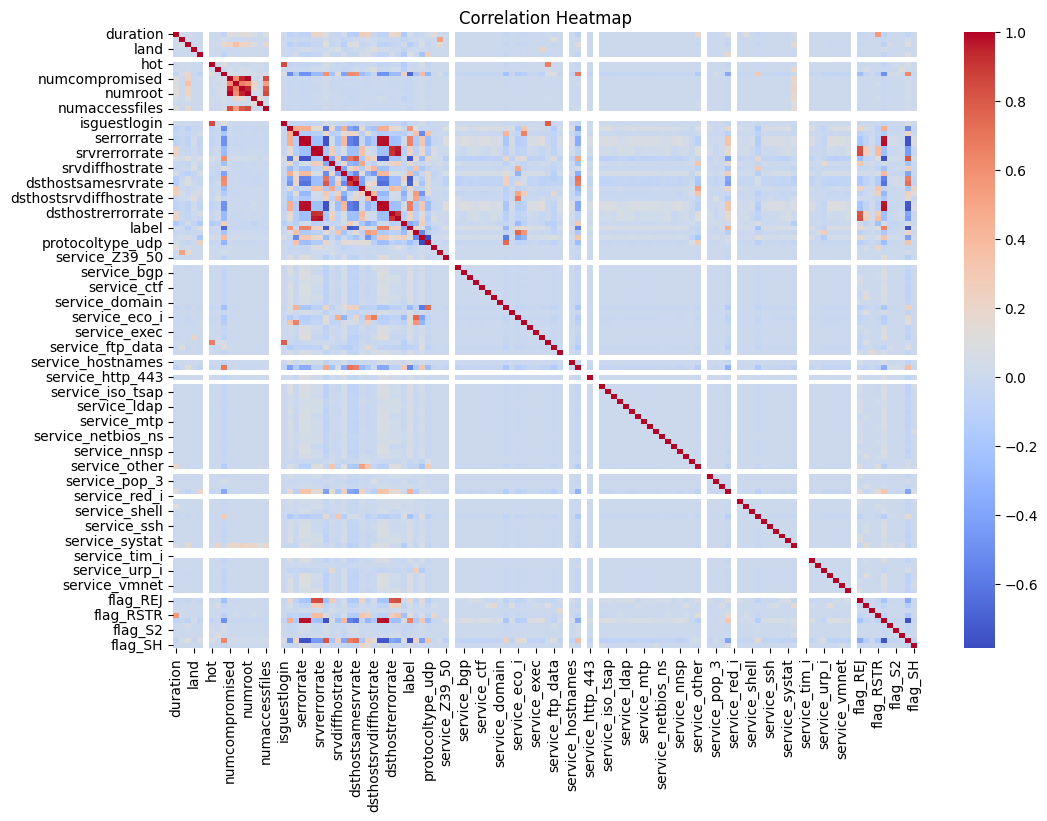

In [16]:
#Correlation Heatmap
import numpy as np

sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(12,8))
sns.heatmap(sample_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

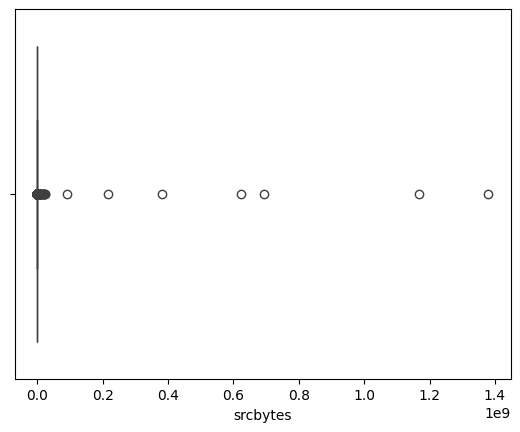

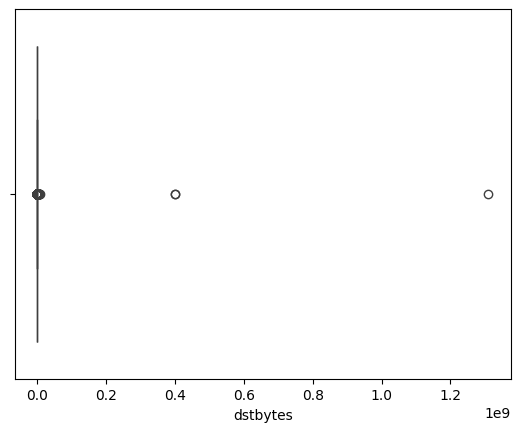

In [17]:
#Outlier Check
sns.boxplot(x=df['srcbytes'])
plt.show()

sns.boxplot(x=df['dstbytes'])
plt.show()

Hypothesis Testing

In [18]:
#T Test
from scipy.stats import ttest_ind

normal = df[df['label'] == 0]['srcbytes']
attack = df[df['label'] == 1]['srcbytes']

t_stat, p_value = ttest_ind(normal, attack)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -2.101656020563486
P-value: 0.03558539933331456


P-value = 0.035 (< 0.05)
→ statistically significant

Conclusion:

There is a difference in srcbytes between normal and attack traffic
Your hypothesis is TRUE

In [19]:
print("Normal mean:", normal.mean())
print("Attack mean:", attack.mean())

Normal mean: 13133.279331185127
Attack mean: 82820.14132696572


Model Building

In [20]:
#Split Data
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(100778, 123) (25195, 123)


In [21]:
#Scale Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
#Train Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
#Predictions
y_pred = model.predict(X_test)

In [24]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9893232784282596
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13422
           1       0.99      0.99      0.99     11773

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



Hypothesis result:
* Normal mean: 13K
* Attack mean: 82K

Clear difference: Attacks generally involve higher data transfer

Model performance:
* Accuracy: 98.9%
* Precision/Recall: ~0.99

#Improve Model

In [25]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [26]:
#Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9994443341932924
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13422
           1       1.00      1.00      1.00     11773

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [27]:
import pandas as pd

importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(10))

srcbytes              0.137860
dstbytes              0.117125
samesrvrate           0.089237
flag_SF               0.070268
dsthostsamesrvrate    0.056168
count                 0.050453
lastflag              0.046866
dsthostdiffsrvrate    0.038121
loggedin              0.038005
diffsrvrate           0.031325
dtype: float64


#Key Insights

Most important features:

1. srcbytes, dstbytes → traffic volume matters
2. samesrvrate, diffsrvrate → behavior patterns
3. flag_SF, lastflag → connection status
4. count → connection frequency

Conclusion:

Attacks are characterized by abnormal traffic volume + unusual connection patterns.

#Hypothesis 2
Chi-Square Test

In [28]:
from scipy.stats import chi2_contingency

# Use original dataframe before encoding if possible
contingency = pd.crosstab(df['protocoltype_tcp'], df['label'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("P-value:", p)

Chi2: 355.2726571563959
P-value: 3.012783619355071e-79


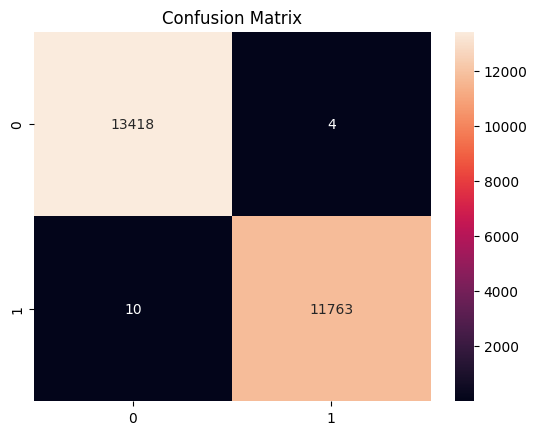

In [29]:
#model validation
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [30]:
#model saving
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Hypothesis 2 (Protocol vs Attack):

P-value ≈ 3e-79 (<< 0.05)
Strong statistical significance

Conclusion:

Protocol type is strongly associated with anomalies.

Confusion Matrix

Values:

TN = 13418
FP = 4
FN = 10
TP = 11763

Errors are extremely low

Conclusion:

Model detects anomalies with very high precision and recall, with minimal misclassification.

#Random Forest model

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [40]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
y_pred_rf = rf.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9994443341932924
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13422
           1       1.00      1.00      1.00     11773

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [44]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False).head(10))

srcbytes              0.137860
dstbytes              0.117125
samesrvrate           0.089237
flag_SF               0.070268
dsthostsamesrvrate    0.056168
count                 0.050453
lastflag              0.046866
dsthostdiffsrvrate    0.038121
loggedin              0.038005
diffsrvrate           0.031325
dtype: float64


Top features:

srcbytes, dstbytes → traffic volume
samesrvrate, diffsrvrate → connection behavior
flag_SF, loggedin → session status

This is exactly what anomaly detection should rely on

In [45]:
#Validate model
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [46]:
y_prob = rf.predict_proba(X_test)[:,1]

In [47]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

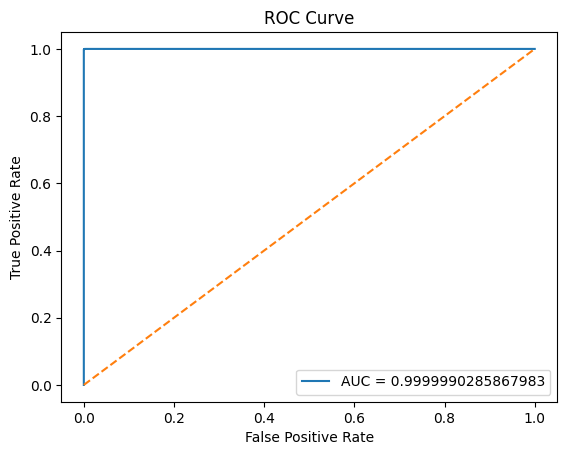

In [48]:
plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The dataset is highly structured and separable. Features like srcbytes, dstbytes, and connection rates clearly distinguish normal and attack traffic.

In [49]:
print("Logistic Regression Accuracy:", 0.989)
print("Random Forest Accuracy:", 0.9994)
print("Random Forest AUC:", roc_auc)

Logistic Regression Accuracy: 0.989
Random Forest Accuracy: 0.9994
Random Forest AUC: 0.9999990285867983


Random Forest performs slightly better due to its ability to capture non-linear relationships.

In [31]:
joblib.dump(rf, "model.pkl")

['model.pkl']

#Flask Deployment

In [32]:
pip install flask

In [34]:
!pip install pyngrok

In [33]:
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)

model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

@app.route('/')
def home():
    return "Network Anomaly Detection API"

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json['features']
    data = np.array(data).reshape(1, -1)

    data = scaler.transform(data)
    prediction = model.predict(data)

    return jsonify({'prediction': int(prediction[0])})

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [36]:
df.to_csv("final_data.csv", index=False)

In [37]:
df_original = pd.read_csv("Network_anomaly_data.csv")
df_original['label'] = df_original['attack'].apply(lambda x: 0 if x == 'normal' else 1)

df_original.to_csv("tableau_data.csv", index=False)

In [38]:
df_original['label_name'] = df_original['label'].map({0: 'Normal', 1: 'Attack'})
df_original.to_csv("tableau_data.csv", index=False)